## Project Objective
The goal of this project is to perform exploratory data analysis on the Titanic dataset 
to understand the factors that affected passenger survival.

In [1]:
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
import matplotlib.pyplot as plt # Basic plotting
import seaborn as sns # Advanced visualizations

In [2]:
# Loading the Titanic dataset
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape # 891 rows and 12 columns

(891, 12)

In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
df.isnull().sum() # columns Age, Cabin, and Embarked have missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.duplicated().sum() # no duplicates 

np.int64(0)

In [12]:
print(np.mean(df['Age']))
print(np.min(df['Age']))
print(np.max(df['Age']))

29.69911764705882
0.42
80.0


In [11]:
df.loc[df['Age'] == df['Age'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


In [12]:
df[df['Age'] == df['Age'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


In [13]:
df[df['Age'] == df['Age'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


<Axes: xlabel='Age', ylabel='Count'>

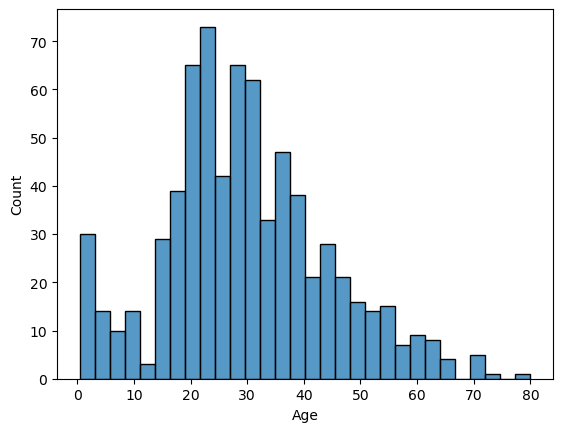

In [14]:
    sns.histplot(df['Age'], bins=30) 
# so from the shape of the distribution, tells us the Age distribution is not normal. It is skewed with outliers probably.
    # 70+ ages are not outlairs, it is possible to have people with such ages onboard
# Therefore: Use MEDIAN, not mean. to fill the null values of age

# Mean is pulled toward outliers (high ages, or weird small ages like 0.42).
# Median is robust and gives a more reliable central value for skewed data.

<Axes: xlabel='Age'>

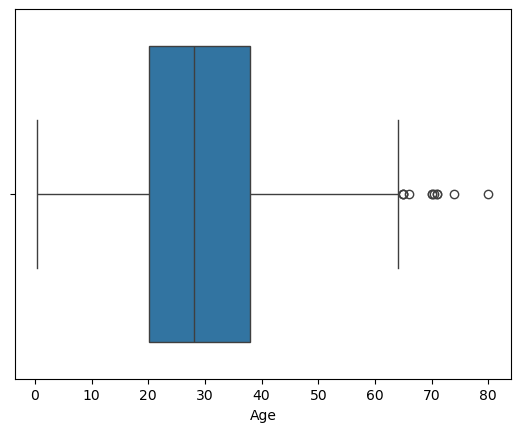

In [16]:
sns.boxplot(x=df['Age'])
#When a boxplot marks values above ~65 as outliers, it does NOT mean those ages are invalid or corrupted.
#It means:

#Those values are far from the median compared to the rest of the data.
#This is a statistical outlier, not a data corruption outlier.

In [17]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [18]:
df[df['Age'] <= 10] # age less than or equal to 10 people

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,PP 9549,16.7000,G6,S
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.00,3,1,349909,21.0750,NaN,S
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,NaN,C
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.00,4,2,347082,31.2750,NaN,S
852,853,0,3,"Boulos, Miss. Nourelain",female,9.00,1,1,2678,15.2458,NaN,C


In [19]:
print(df['Age'].loc[df['Age'] <= 10].count()) # age less than or equal to 10 people

64


In [20]:
(df['Age'] <= 10).sum() # alternate

np.int64(64)

In [21]:
# now to fill null values in age we use median, since distribution was skewed. (Using fillna())

In [21]:
df['Age'] = df['Age'].fillna(df['Age'].median())
#This changes df in place.

In [22]:
df.isnull().sum() # age null values gone.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
df[['Cabin']]

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


<Axes: xlabel='Cabin', ylabel='count'>

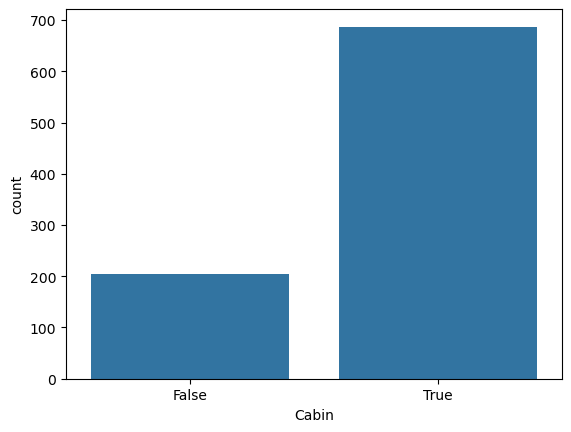

In [18]:
sns.countplot(x = df['Cabin'].isna() , data = df) ## Visualizing missing vs non-missing values in Cabin column

In [26]:
df['Cabin'].mode()

# Mode is standard for categorical missing values.
# For Cabin, because missing is so high, it’s often better to fill with a placeholder or extract deck letters instead of blindly using mode.

0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: object

In [23]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [24]:
df.isnull().sum() # Missing values in the Cabin column have been successfully handled.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [34]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [28]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#The Embarked column contains only a small number of missing values.
# Therefore, filling them with the most frequent category (mode) is ok.

In [30]:
df.isnull().sum() # Embarked null values handled.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## Univariate Analysis:

<Axes: xlabel='Age', ylabel='Count'>

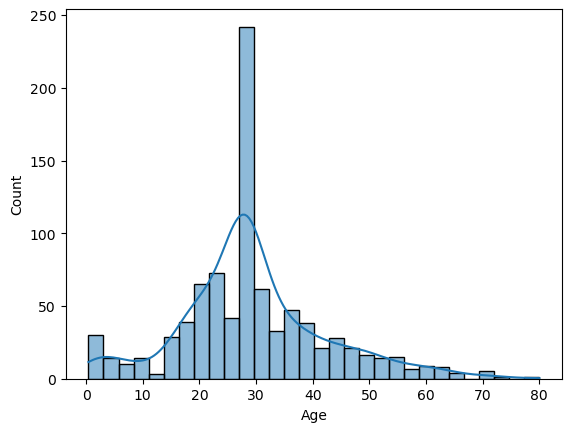

In [31]:
sns.histplot(x = df['Age'] , data = df , kde = True) 
# Observation:
# age has a skewed histplot
# Most passengers fall in the young adult & middle-aged category

<Axes: xlabel='Fare', ylabel='Count'>

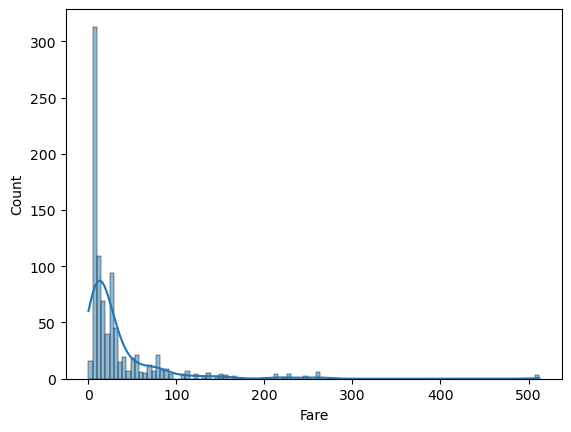

In [32]:
sns.histplot(x = df['Fare'] , data = df , kde = True) 
# Observation:
# The Fare distribution is highly right-skewed.
# Most passengers paid low fares, while only a few paid very high prices.

<Axes: xlabel='Sex', ylabel='count'>

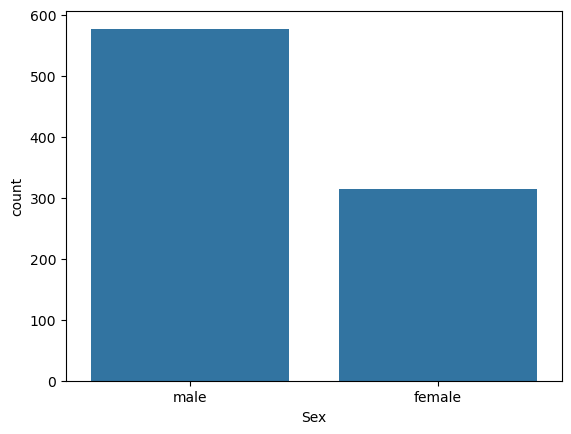

In [33]:
sns.countplot(x = df['Sex'] , data = df) 
# Observation:
# The dataset contains more male passengers than female.

<Axes: xlabel='Pclass', ylabel='count'>

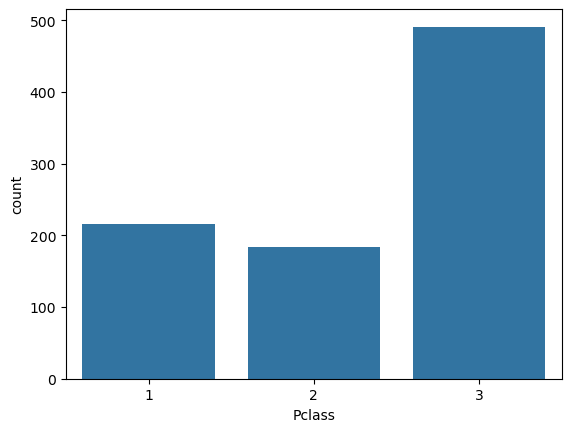

In [34]:
sns.countplot(x='Pclass', data=df)
# Observation:
# Most passengers belonged to the third class, followed by second and first class.

<Axes: xlabel='Embarked', ylabel='count'>

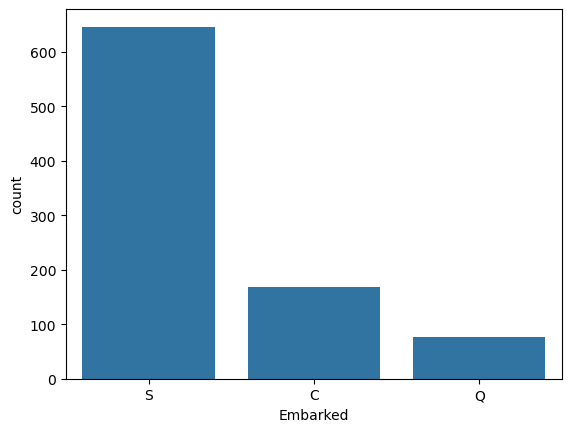

In [35]:
sns.countplot(x='Embarked', data=df)
# Observation:
# Most passengers boarded from (S) followed by (C) and (Q).

## bivariate analysis:

<Axes: xlabel='Sex', ylabel='Survived'>

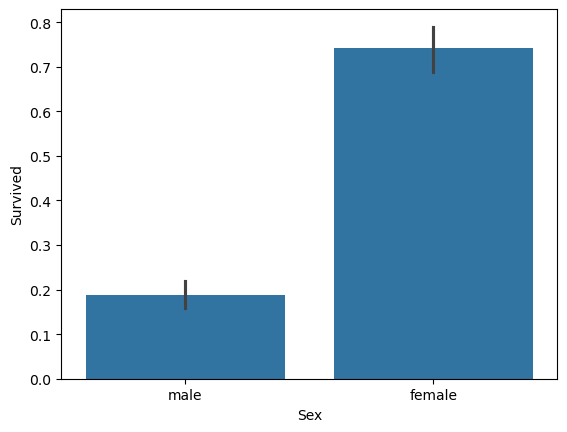

In [36]:
sns.barplot(x='Sex', y='Survived', data=df)
# Observation:
# Female passengers had a significantly higher survival rate compared to male passengers.

<Axes: xlabel='Survived', ylabel='count'>

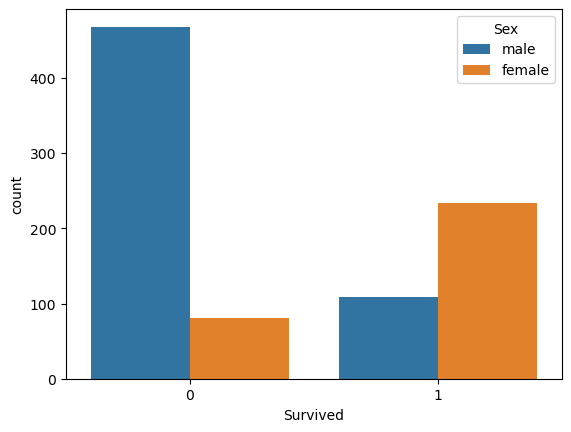

In [38]:
sns.countplot(x='Survived', data=df , hue='Sex')

# Observation:
# A higher number of male passengers did not survive compared to female passengers.
# Female passengers show a higher survival count.

<Axes: xlabel='Sex', ylabel='count'>

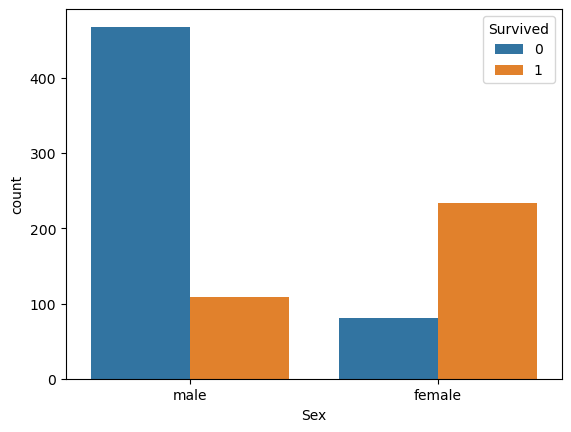

In [39]:
sns.countplot(x ='Sex', data=df, hue='Survived') 
#females survived more than males.

<Axes: xlabel='Pclass', ylabel='Survived'>

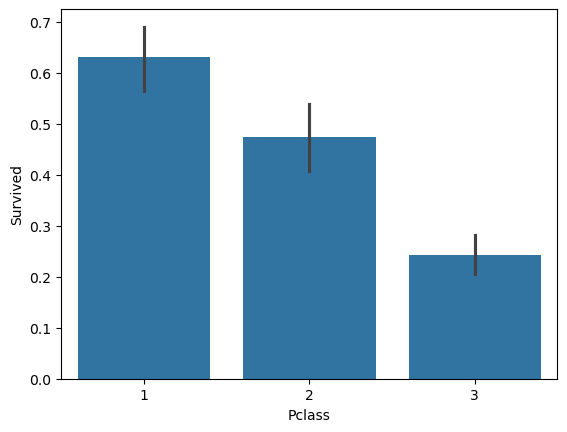

In [41]:
sns.barplot(x='Pclass', y='Survived', data=df)
# Observation:
# Passengers in higher classes had better survival rates compared to those in lower classes.

<Axes: xlabel='Pclass', ylabel='count'>

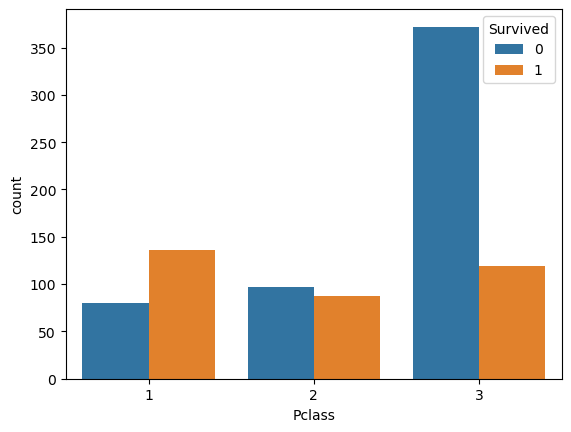

In [42]:
sns.countplot(x='Pclass' , data=df , hue='Survived')
# Observation:
# First-class passengers show higher survival counts, while third-class passengers have the highest number of non survivors.

<Axes: xlabel='Embarked', ylabel='Survived'>

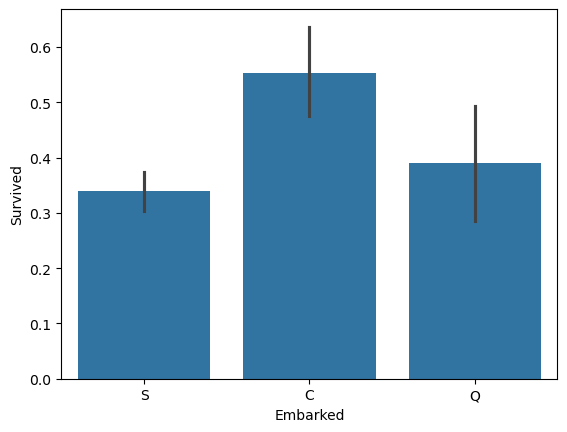

In [43]:
sns.barplot(x='Embarked', y='Survived', data=df)
# Observation:
# Passengers who embarked from 'C' had higher survival rates,
# while those from 'S' have comparatively lower survival rates.

<Axes: xlabel='Embarked', ylabel='count'>

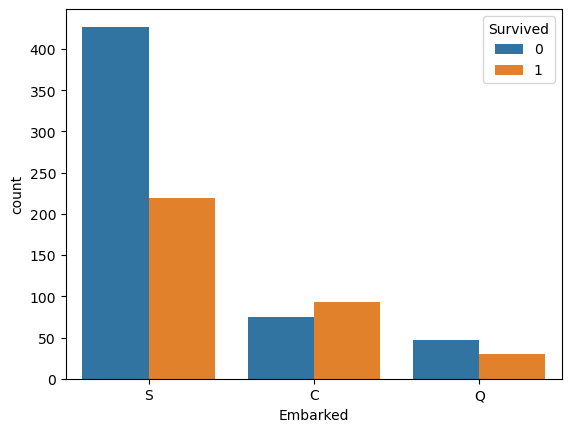

In [44]:
sns.countplot(x='Embarked' , data=df , hue='Survived')
# conclusion : Embarked "C" passengers showed slightly higher survival compared to 'S' and 'Q'.

<Axes: xlabel='Age', ylabel='Count'>

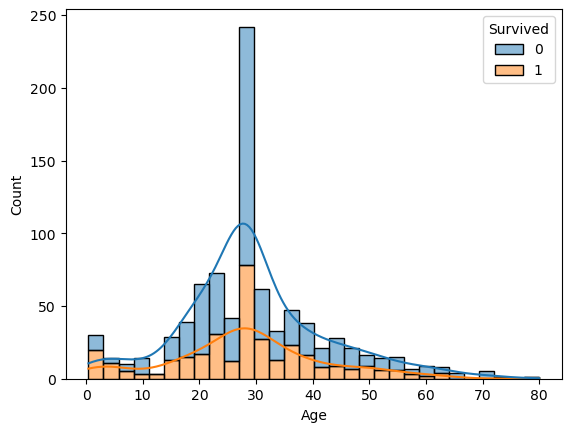

In [46]:
# survived by age:
sns.histplot(x = 'Age' , data = df , hue = 'Survived' , multiple= 'stack', kde=True)
# conclusion: Younger passengers show relatively higher likely to survive

<Axes: xlabel='Age', ylabel='Count'>

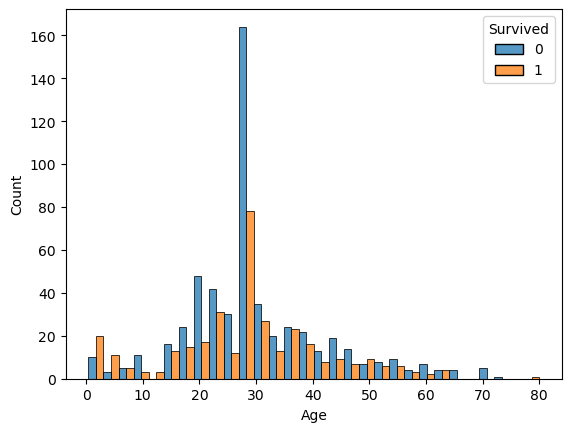

In [48]:
sns.histplot(x='Age', data=df, hue='Survived', multiple='dodge', kde=False)

<Axes: xlabel='Age', ylabel='Count'>

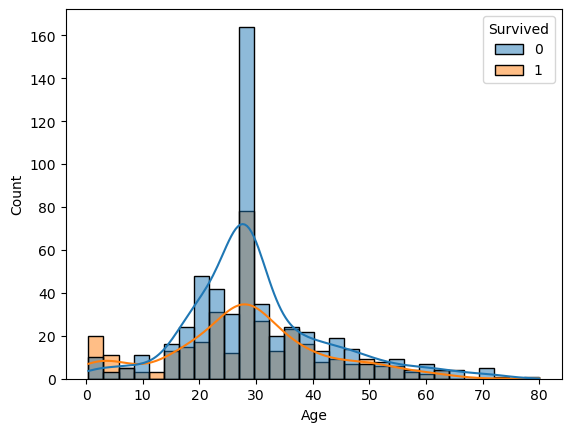

In [49]:
sns.histplot(x='Age', data=df, hue='Survived', multiple='layer', kde=True)

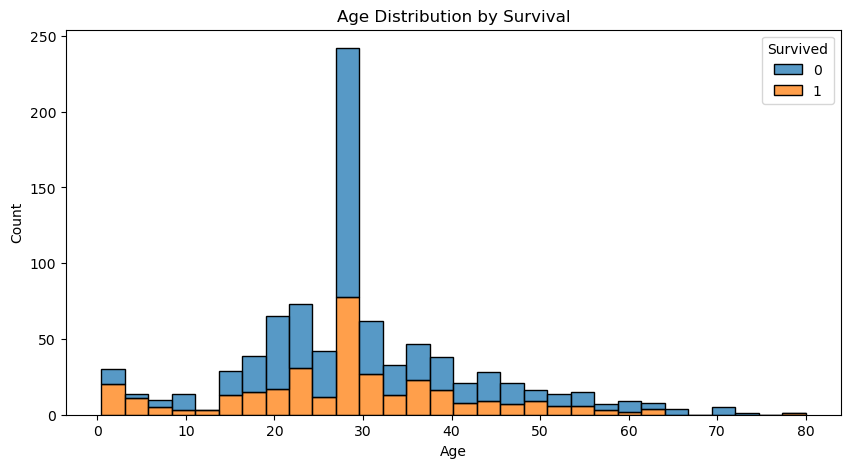

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(x='Age', data=df, hue='Survived', bins=30, multiple='stack')
plt.title('Age Distribution by Survival')
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

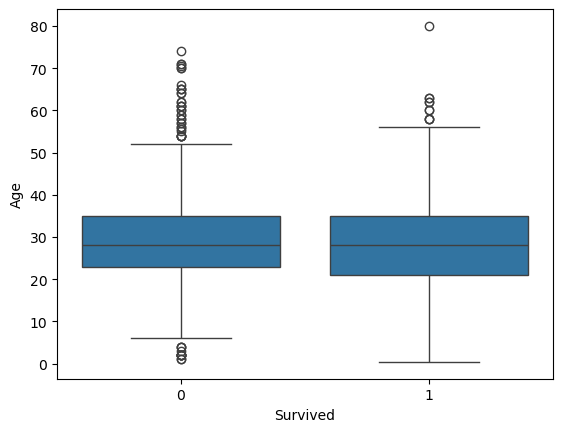

In [51]:
sns.boxplot(x='Survived', y='Age', data=df)
# Observation:
# The median age of survivors is slightly lower than that of non-survivors.
# This means that younger passengers had relatively better survival chances.

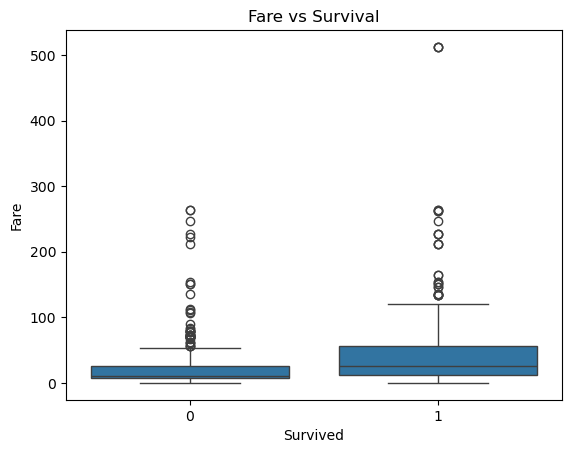

In [52]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')
plt.show()

#Conclusion:
#Survivors generally paid higher fares

#Non-survivors cluster at lower fares

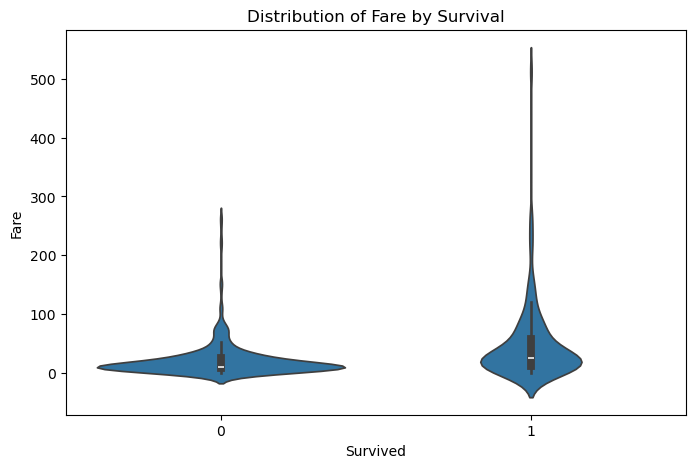

In [54]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Survived', y='Fare', data=df)
plt.title('Distribution of Fare by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

# Observation:
# Survivors show a wider and higher fare distribution,indicating that passengers who paid higher fares had better survival chances.

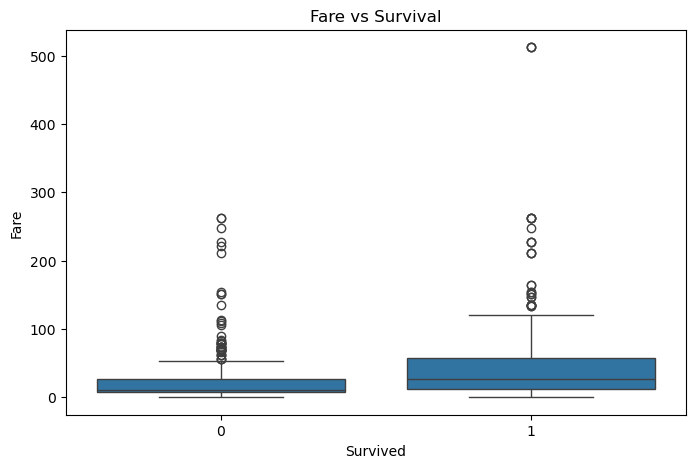

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

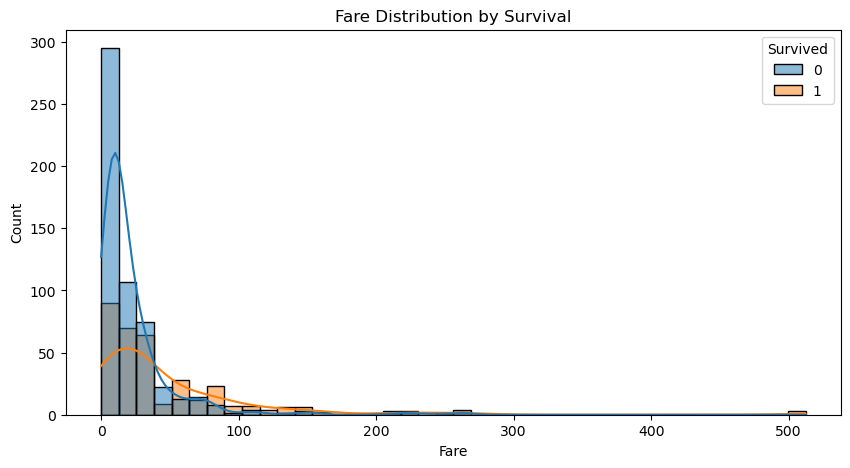

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Fare', hue='Survived', bins=40, kde=True, multiple='layer')
plt.title('Fare Distribution by Survival')
plt.show()

# Observation:
# The distribution shows that survivors tend to have higher fare values, while non-survivors are more concentrated in the lower fare range.

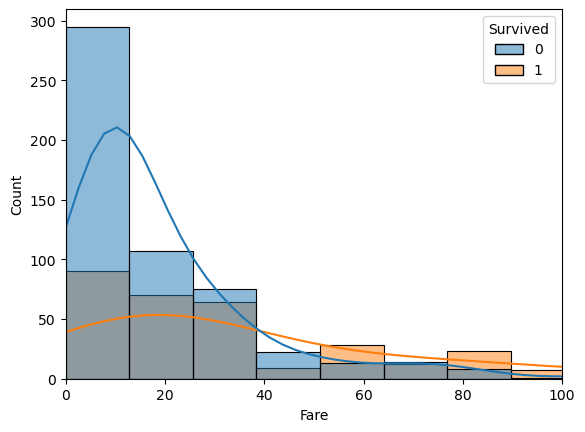

In [58]:
sns.histplot(data=df, x='Fare', hue='Survived', bins=40, kde=True, multiple='layer')
plt.xlim(0, 100)
plt.show()

# Observation:
# After limiting extreme values, the plot shows more clearly that, survivors tend to have higher fares within the common price range.
#Some passengers paid extremely high fares, which can may visualizations.
# By limiting the range, we obtain a clearer view of typical passenger behavior and survival patterns.


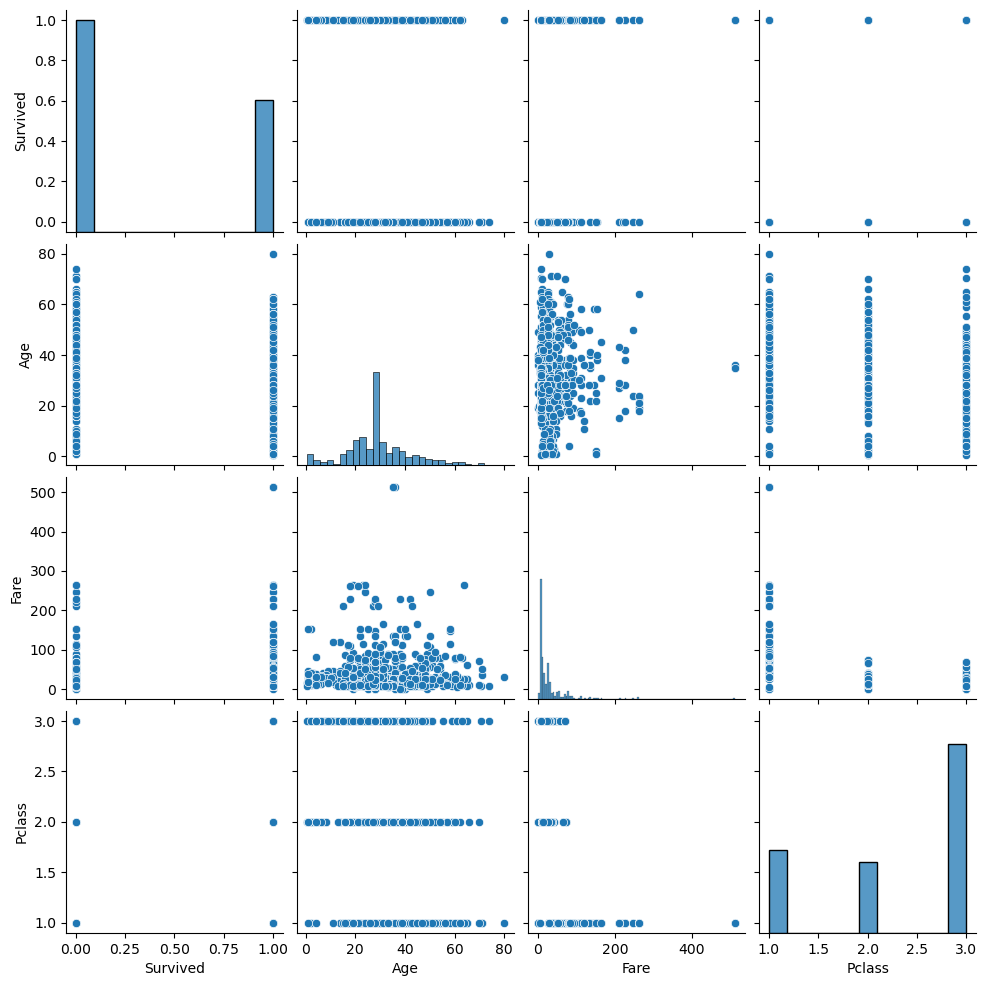

In [59]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']])

### Pairwise Feature Relationships

The pairplot helps us understand how survival is related to age, fare, and passenger class.
From the plots, we can observe that:

- Passengers who paid higher fares were more likely to survive.
- Younger passengers appear more frequently among the survivors.
- Passenger class plays an important in survival outcome.


## Feature Engineering Ideas

In [60]:
# Feature Engineering: Extracting Title from Name

# Extracting passenger titles (Mr, Mrs, Miss, etc.) from the Name column
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Displaying unique extracted titles
df['Title'].value_counts()


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [62]:
#  Creating Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [63]:
# Creating IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)


In [65]:
# Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']


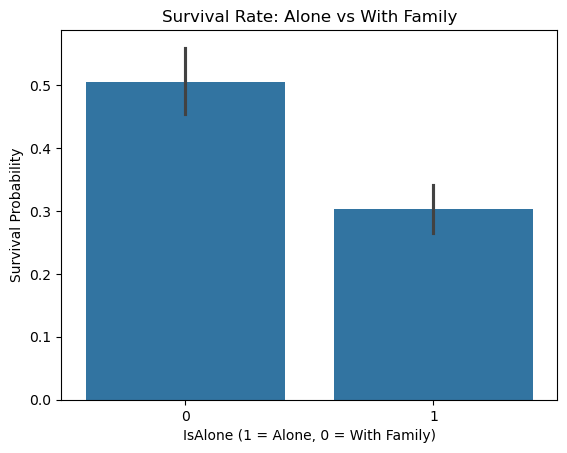

In [69]:
#Survival Rate by Traveling Alone:
sns.barplot(x='IsAlone', y='Survived', data=df)

plt.title("Survival Rate: Alone vs With Family")
plt.xlabel("IsAlone (1 = Alone, 0 = With Family)")
plt.ylabel("Survival Probability")
plt.show()

# Observation:
# Passengers traveling with family had higher survival rates, compared to those traveling alone.


In [66]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,0,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,1,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,1,8.05000


## Final Conclusion

In this project Key findings include:
- Female passengers had higher survival rates.
- Higher-class and higher-fare passengers were more likely to survive.
- Younger passengers had better survival outcomes.
- Passengers traveling alone had lower survival chances.

Data cleaning and feature engineering were applied to improve data quality.

